#  AI-Driven Screening for Carbon Capture Materials
### Predicting CO₂ Uptake in Metal-Organic Frameworks (MOFs)

**Goal:** Build a machine learning model that predicts CO₂ uptake capacity  
of a MOF purely from its geometric structure — enabling rapid screening  
of 90,000+ candidates without expensive lab experiments.

---

##  Step 1 — Import libraries for EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

##  Step 2 — Load Data

In [3]:
df = pd.read_csv("C://Users//HP//OneDrive//Documents//carbon_capture//data.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (324426, 42)
Columns: ['MOFname', 'CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'excess_CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2_uptake_P0.10bar_T363K [mmol/g]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'excess_CO2_uptake_P0.10bar_T363K [mmol/g]', 'CO2_uptake_P0.70bar_T413K [mmol/g]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'excess_CO2_uptake_P0.70bar_T413K [mmol/g]', 'working_capacity_vacuum_swing [mmol/g]', 'working_capacity_temperature_swing [mmol/g]', 'CO2_binary_uptake_P0.15bar_T298K [mmol/g]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]', 'heat_adsorption_error_CO

##  Step 3 — Basic Inspection
Check data types and first few rows to understand what each column represents.

In [4]:
df.head()

,MOFname,CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_error_P0.15bar_T298K [mmol/g],heat_adsorption_CO2_P0.15bar_T298K [kcal/mol],heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol],excess_CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_P0.10bar_T363K [mmol/g],CO2_uptake_error_P0.10bar_T363K [mmol/g],heat_adsorption_CO2_P0.10bar_T363K [kcal/mol],heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol],...,void_fraction,void_volume [cm^3/g],largest_free_sphere_diameter [A],largest_included_sphere_along_free_sphere_path_diameter [A],largest_included_sphere_diameter [A],functional_groups,metal_linker,organic_linker1,organic_linker2,topology
0,str_m5_o16_o16_sra_sym.77,5.955197,0.117622,9.223227,0.546586,5.955127,0.840043,0.295803,7.972884,5.106942,...,0.14835,0.1480,4.61370,3.78047,4.61370,Pr,9,16,16,sra
1,str_m5_o16_o16_sra_sym.37,5.715251,0.034598,8.391884,0.149962,5.715251,0.901656,0.283054,8.343676,4.785696,...,0.16099,0.1624,4.10210,3.39756,4.10055,OMe,9,16,16,sra
2,str_m5_o13_o18_sra_sym.149,5.524486,0.155094,8.674098,0.753841,5.524486,0.688965,0.191963,7.546794,3.803472,...,0.17980,0.1810,4.24711,3.26179,4.24603,NO2,9,13,18,sra
3,str_m5_o2_o18_sra_sym.4,5.517258,0.084320,10.791553,0.514052,5.517258,1.881691,0.166854,9.246778,1.511943,...,0.10245,0.0922,4.11419,2.93595,3.63925,H,9,2,18,sra
4,str_m5_o16_o16_sra_sym.31,5.451593,0.051989,8.711414,0.260774,5.451476,0.797098,0.254966,8.247735,4.814885,...,0.15634,0.1583,4.37077,3.49681,4.16451,Et,9,16,16,sra


In [5]:
df.dtypes

MOFname                                                            str
CO2_uptake_P0.15bar_T298K [mmol/g]                             float64
CO2_uptake_error_P0.15bar_T298K [mmol/g]                       float64
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                  float64
heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]            float64
excess_CO2_uptake_P0.15bar_T298K [mmol/g]                      float64
CO2_uptake_P0.10bar_T363K [mmol/g]                             float64
CO2_uptake_error_P0.10bar_T363K [mmol/g]                       float64
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                  float64
heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]            float64
excess_CO2_uptake_P0.10bar_T363K [mmol/g]                      float64
CO2_uptake_P0.70bar_T413K [mmol/g]                             float64
CO2_uptake_error_P0.70bar_T413K [mmol/g]                       float64
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                  float64
heat_a

##  Step 4 — Missing Values
Identify which columns have nulls and what percentage of data is affected.  


In [6]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
})

print(missing_df[missing_df['missing_count'] > 0])

                                                    missing_count  missing_pct
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                2087         0.64
heat_adsorption_error_CO2_P0.15bar_T298K [kcal/...           2087         0.64
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                2094         0.65
heat_adsorption_error_CO2_P0.10bar_T363K [kcal/...           2094         0.65
CO2_uptake_P0.70bar_T413K [mmol/g]                            167         0.05
CO2_uptake_error_P0.70bar_T413K [mmol/g]                      167         0.05
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                2100         0.65
heat_adsorption_error_CO2_P0.70bar_T413K [kcal/...           2100         0.65
excess_CO2_uptake_P0.70bar_T413K [mmol/g]                     167         0.05
heat_adsorption_CO2_binary_P0.15bar_T298K [kcal...           2477         0.76
heat_adsorption_error_CO2_binary_P0.15bar_T298K...           2477         0.76
heat_adsorption_N2_binary_P0.85bar_T298K [kcal/...  

##  Step 5 — Target Variable Distribution
Our target is `CO2_uptake_P0.15bar_T298K` — CO₂ uptake at standard  
flue gas conditions (0.15 bar, 298 K).  
We check if it's skewed — skewed targets are harder to predict and  
may need a log transform later.

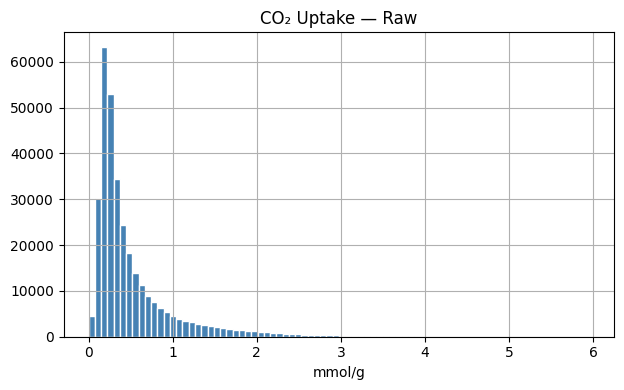

count    324426.000000
mean          0.517388
std           0.532612
min           0.000000
25%           0.204142
50%           0.319067
75%           0.605401
max           5.955197
Name: CO2_uptake_P0.15bar_T298K [mmol/g], dtype: float64


In [7]:
TARGET = 'CO2_uptake_P0.15bar_T298K [mmol/g]'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[TARGET].hist(bins=80, color='steelblue', edgecolor='white')
plt.title('CO₂ Uptake — Raw')
plt.xlabel('mmol/g')

"""plt.subplot(1, 2, 2)
np.log1p(df[TARGET]).hist(bins=80, color='coral', edgecolor='white')
plt.title('CO₂ Uptake — log1p transformed')
plt.xlabel('log1p(mmol/g)')"""

plt.tight_layout()
plt.show()

print(df[TARGET].describe())

##  Step 6 — Geometric Feature Distributions
These are the structural descriptors we will use as model inputs. 

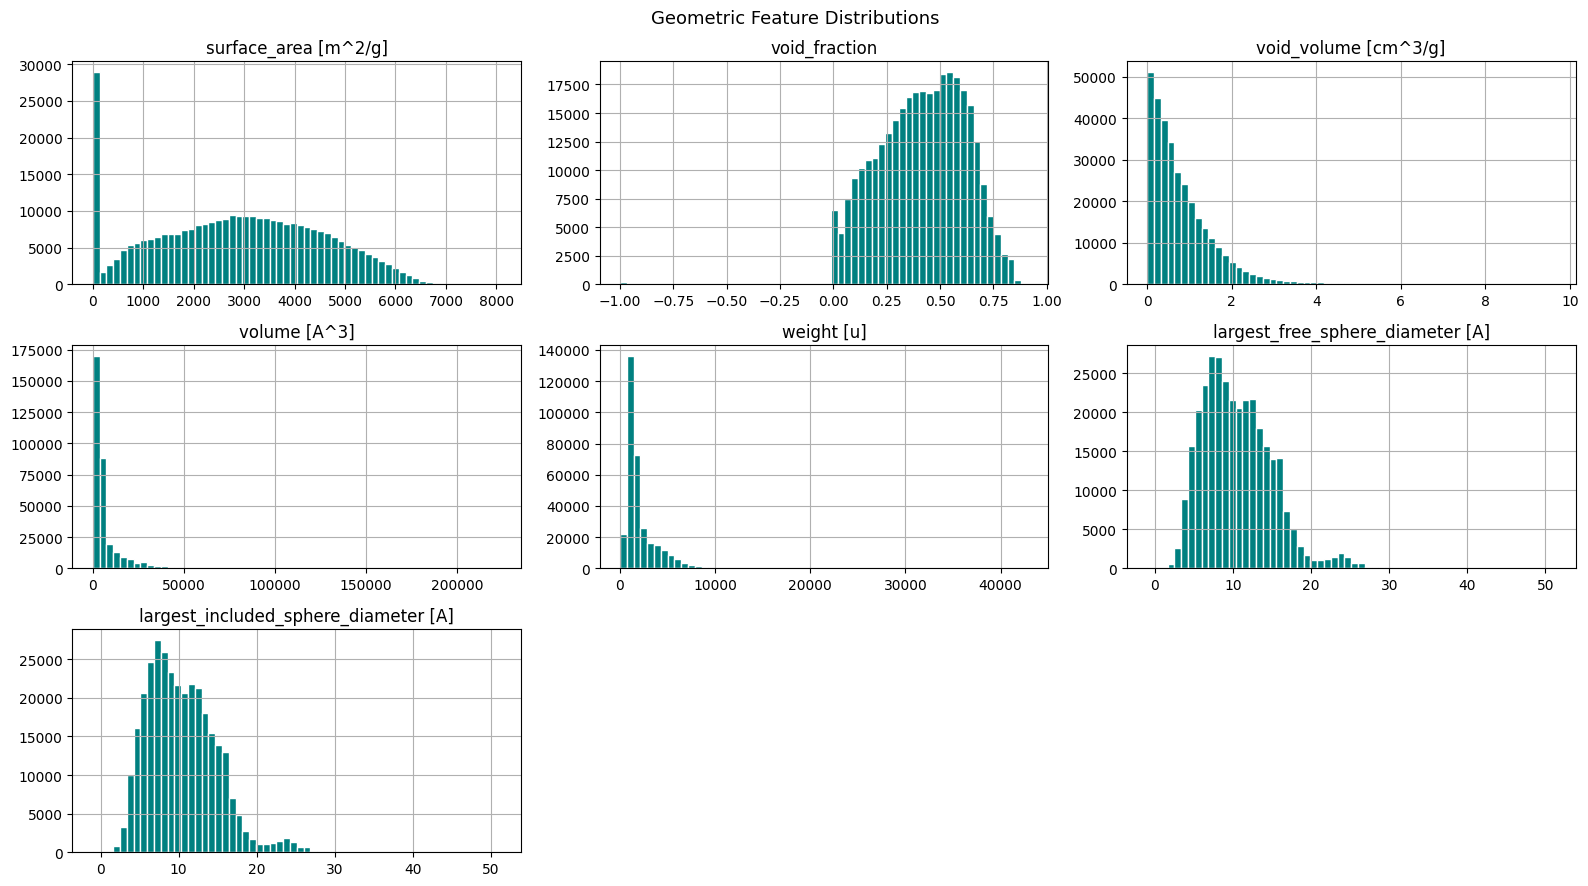

In [8]:
geo_cols = [
    'surface_area [m^2/g]', 'void_fraction',
    'void_volume [cm^3/g]', 'volume [A^3]', 'weight [u]',
    'largest_free_sphere_diameter [A]',
    'largest_included_sphere_diameter [A]'
]

df[geo_cols].hist(bins=60, figsize=(16, 9), color='teal', edgecolor='white')
plt.suptitle('Geometric Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

##  Step 7 — Correlation Heatmap
Shows how strongly each geometric feature correlates with CO₂ uptake.Values close to +1 or -1 = strong relationship with target.  

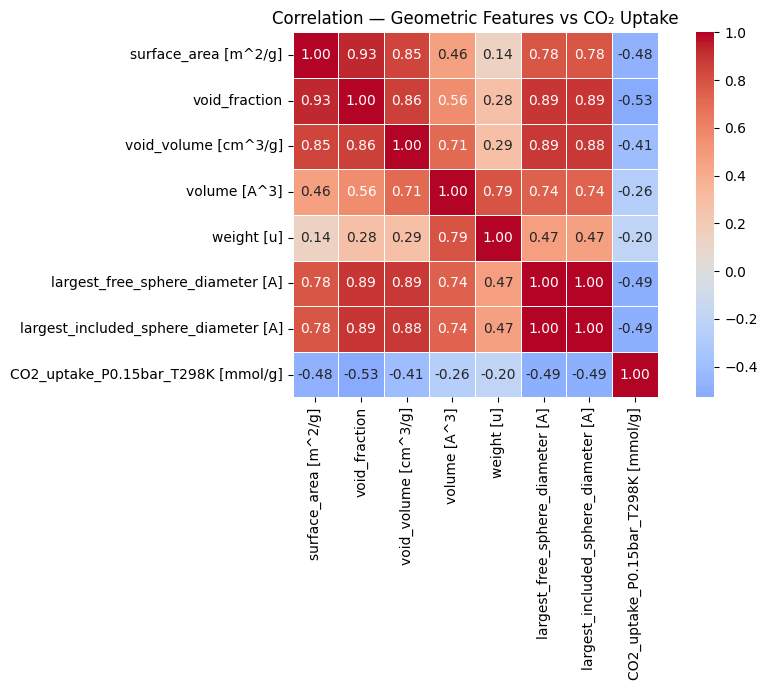

In [9]:
corr_cols = geo_cols + [TARGET]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation — Geometric Features vs CO₂ Uptake')
plt.tight_layout()
plt.show()


##  Step 8 — Categorical Columns Overview
Check how many unique values each categorical column has —  
this decides which encoding strategy we use later.

In [10]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"{col:30s} → {df[col].nunique()} unique values")

MOFname                        → 324426 unique values
functional_groups              → 400 unique values
topology                       → 11 unique values


C:\Users\HP\AppData\Local\Temp\ipykernel_20568\3239662066.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


##  Step 9 — Data Cleaning

In [11]:
error_cols = [c for c in df.columns if 'error' in c.lower()]
print("Dropping:", error_cols)
df = df.drop(columns=error_cols)
print("\nShape after dropping error cols:", df.shape)

Dropping: ['CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_binary_P0.15bar_T298K [kcal/mol]', 'N2_binary_uptake_error_P0.85bar_T298K [mmol/g]', 'heat_adsorption_error_N2_binary_P0.85bar_T298K [kcal/mol]']

Shape after dropping error cols: (324426, 32)


In [12]:
todrop = [
    'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]',
    'excess_CO2_uptake_P0.15bar_T298K [mmol/g]',
    'CO2_uptake_P0.10bar_T363K [mmol/g]',
    'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]',
    'excess_CO2_uptake_P0.10bar_T363K [mmol/g]',
    'CO2_uptake_P0.70bar_T413K [mmol/g]',
    'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]',
    'excess_CO2_uptake_P0.70bar_T413K [mmol/g]',
    'working_capacity_vacuum_swing [mmol/g]',
    'working_capacity_temperature_swing [mmol/g]',
    'CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
    'heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]',
    'excess_CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
    'N2_binary_uptake_P0.85bar_T298K [mmol/g]',
    'heat_adsorption_N2_binary_P0.85bar_T298K [kcal/mol]',
    'excess_N2_binary_uptake_P0.85bar_T298K [mmol/g]',
    #'CO2/N2_selectivity',
]
df = df.drop(columns=['MOFname'])
df = df.drop(columns=todrop)
df.shape

(324426, 15)

In [13]:
#Handle Missing Values
df.dropna(inplace=True)


In [14]:
print("Final shape:", df.shape)
print("Null values remaining:", df.isnull().sum().sum())
print("\nRemaining columns:")
print(df.columns.tolist())

Final shape: (322429, 15)
Null values remaining: 0

Remaining columns:
['CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2/N2_selectivity', 'volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'functional_groups', 'metal_linker', 'organic_linker1', 'organic_linker2', 'topology']


##  Step 10 — Encoding Categorical Columns
Machine learning models only understand numbers.
We have 3 categorical columns, each needing a different strategy:

| Column | Unique Values | Strategy |
|---|---|---|
| `functional_groups` | ~400 | Frequency Encoding |
| `topology` | 11 | One-Hot Encoding |
| `metal_linker` | 7 | One-Hot Encoding |
| `organic_linker1/2` | 58 | Already integers  |

In [15]:
# Frequency encoding for functional_groups column and one hot encoding for topology and metal linker column
freq = df['functional_groups'].value_counts()
df['functional_groups'] = df['functional_groups'].map(freq)
print("Frequency encoded: functional_groups")
df = pd.get_dummies(df, columns=['topology','metal_linker'])

print("One-hot encoded: topology and metal linkers")
print("\nNew shape:", df.shape)
print("New columns:", df.columns.tolist())

Frequency encoded: functional_groups
One-hot encoded: topology and metal linkers

New shape: (322429, 31)
New columns: ['CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2/N2_selectivity', 'volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'functional_groups', 'organic_linker1', 'organic_linker2', 'topology_acs', 'topology_bcu', 'topology_etb', 'topology_fof', 'topology_nbo', 'topology_pcu', 'topology_pts', 'topology_rht', 'topology_sra', 'topology_tbo', 'topology_the', 'metal_linker_1', 'metal_linker_2', 'metal_linker_3', 'metal_linker_4', 'metal_linker_9', 'metal_linker_10', 'metal_linker_12']


In [16]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [17]:
df.dtypes

CO2_uptake_P0.15bar_T298K [mmol/g]                             float64
CO2/N2_selectivity                                             float64
volume [A^3]                                                   float64
weight [u]                                                     float64
surface_area [m^2/g]                                           float64
void_fraction                                                  float64
void_volume [cm^3/g]                                           float64
largest_free_sphere_diameter [A]                               float64
largest_included_sphere_along_free_sphere_path_diameter [A]    float64
largest_included_sphere_diameter [A]                           float64
functional_groups                                                int64
organic_linker1                                                  int64
organic_linker2                                                  int64
topology_acs                                                     int64
topolo

##  Step 12 — Define x and y
Separate the dataset into:
- **x** — all input features (geometry + encoded categoricals)
- **y** — target variable (CO₂ uptake)


In [18]:
df_model = df.copy()

In [19]:
TARGET = 'CO2_uptake_P0.15bar_T298K [mmol/g]'
y = df[TARGET]
x = df.drop(columns=[TARGET])
x = x.select_dtypes(include='number')
print("x shape:", x.shape)
print("y.shape:", y.shape)
print("\nFeatures going into model:")
print(x.columns.tolist())

x shape: (322429, 30)
y.shape: (322429,)

Features going into model:
['CO2/N2_selectivity', 'volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'functional_groups', 'organic_linker1', 'organic_linker2', 'topology_acs', 'topology_bcu', 'topology_etb', 'topology_fof', 'topology_nbo', 'topology_pcu', 'topology_pts', 'topology_rht', 'topology_sra', 'topology_tbo', 'topology_the', 'metal_linker_1', 'metal_linker_2', 'metal_linker_3', 'metal_linker_4', 'metal_linker_9', 'metal_linker_10', 'metal_linker_12']


##  Step 13 — Train / Validation / Test Split (70 / 15 / 15)

Three separate sets:
- **Train (70%)** — model learns from this
- **Validation (15%)** — monitors overfitting during training via early stopping
- **Test (15%)** — completely untouched until final evaluation

In [20]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y,
    test_size=0.30,
    random_state=42
)
x_test, x_val, y_test, y_val = train_test_split(
    x_temp, y_temp, 
    test_size=0.50, 
    random_state=42
)
print("Training rows:   ", x_train.shape[0])   
print("Validation rows: ", x_val.shape[0])     
print("Test rows:       ", x_test.shape[0]) 

Training rows:    225700
Validation rows:  48365
Test rows:        48364


##  Step 15 — Random Forest Regressor

In [21]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=7,
    min_samples_leaf=3,
    # minimum rows required in each leaf node
    # 1 = very detailed trees
    # try values 1, 2, 4 and compare
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(x_train, y_train)

y_pred_train = rf.predict(x_train)
#y_pred_val   = rf.predict(x_val)
y_pred_test  = rf.predict(x_test)

r2_train = r2_score(y_train, y_pred_train)
#r2_val   = r2_score(y_val,   y_pred_val)
r2_test  = r2_score(y_test,  y_pred_test)
mse_test = mean_squared_error(y_test,y_pred_test)
mse_train = mean_squared_error(y_train,y_pred_train)
mae_test = mean_absolute_error(y_test,y_pred_test)
mae_train = mean_absolute_error(y_train,y_pred_train)

print(f"Train R² : {r2_train:.4f}")
#print(f"Val   R² : {r2_val:.4f}")
print(f"Test  R² : {r2_test:.4f}")
print(f"Gap      : {r2_train - r2_test:.4f}")
print("MSE for test:", mse_test)
print("MSE for train:", mse_train)
print("MAE for train:", mae_train)
print("MAE for test:", mae_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   14.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.5s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s


Train R² : 0.9481
Test  R² : 0.9042
Gap      : 0.0439
MSE for test: 0.02701192295670014
MSE for train: 0.014668884739813984
MAE for train: 0.06979776934583116
MAE for test: 0.0941951051713844


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.5s finished


##  Step 16 — Plots

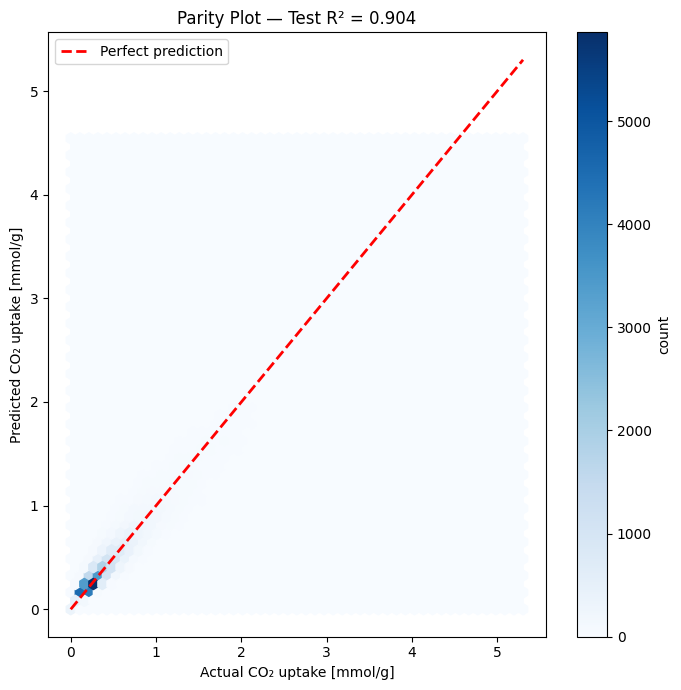

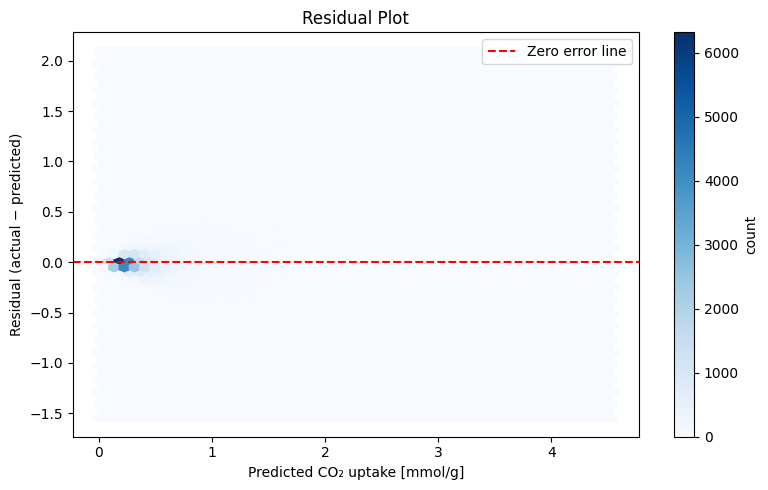

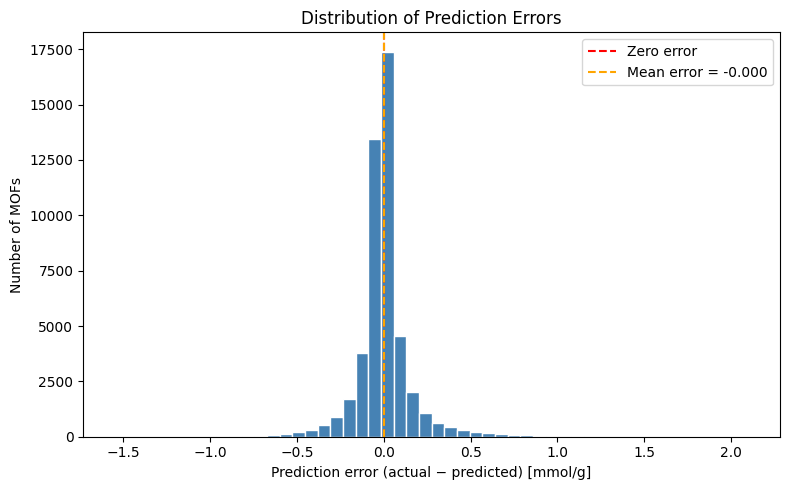


Top 10 most important features:
                                                    feature  importance
                                         CO2/N2_selectivity    0.380039
                       largest_included_sphere_diameter [A]    0.084881
                           largest_free_sphere_diameter [A]    0.081608
                                              void_fraction    0.081596
                                       void_volume [cm^3/g]    0.061359
largest_included_sphere_along_free_sphere_path_diameter [A]    0.055781
                                            organic_linker2    0.040467
                                       surface_area [m^2/g]    0.038896
                                               volume [A^3]    0.034463
                                            organic_linker1    0.028172


C:\Users\HP\AppData\Local\Temp\ipykernel_20568\4199718757.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


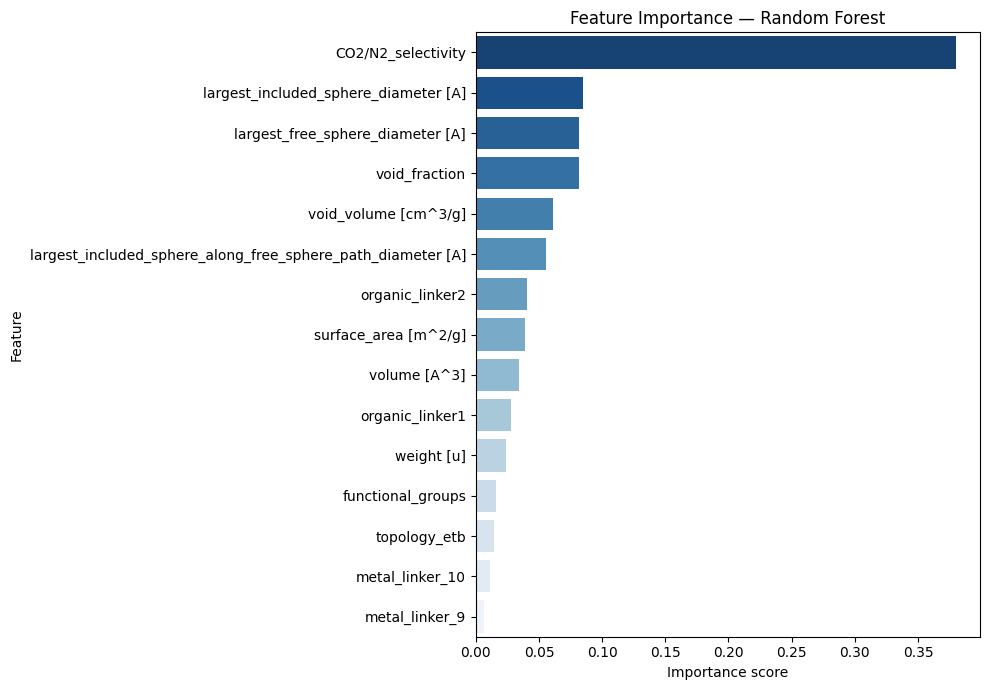

In [22]:
plt.figure(figsize=(7, 7))
plt.hexbin(
    y_test,
    y_pred_test,
    gridsize=50,
    cmap='Blues'
)
plt.colorbar(label='count')

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--', linewidth=2,
    label='Perfect prediction'
)
plt.xlabel('Actual CO₂ uptake [mmol/g]')
plt.ylabel('Predicted CO₂ uptake [mmol/g]')
plt.title(f'Parity Plot — Test R² = {r2_test:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=150, bbox_inches='tight')
plt.show()


# ── PLOT 8: RESIDUAL PLOT ────────────────────────────────────
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 5))
plt.hexbin(
    y_pred_test,
    residuals,
    gridsize=50,
    cmap='Blues'
)
plt.colorbar(label='count')
plt.axhline(
    0,
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='Zero error line'
)
plt.xlabel('Predicted CO₂ uptake [mmol/g]')
plt.ylabel('Residual (actual − predicted)')
plt.title('Residual Plot')
plt.legend()
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()


# ── PLOT 9: ERROR DISTRIBUTION ───────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(
    residuals,
    bins=50,
    color='steelblue',
    edgecolor='white'
)
plt.axvline(
    0,
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='Zero error'
)
plt.axvline(
    residuals.mean(),
    color='orange',
    linewidth=1.5,
    linestyle='--',
    label=f'Mean error = {residuals.mean():.3f}'
)
plt.xlabel('Prediction error (actual − predicted) [mmol/g]')
plt.ylabel('Number of MOFs')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ── PLOT 10: FEATURE IMPORTANCE ──────────────────────────────
import pandas as pd

feature_names = x.columns.tolist()

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_df.head(15),
    x='importance',
    y='feature',
    palette='Blues_r'
)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 17 — SHAP Analysis

In [23]:
!pip install shap
import shap
print("SHAP version:", shap.__version__)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


SHAP explainer created!
x_test_sample shape: (100, 30)
Computing SHAP values for 100 test samples...
SHAP values computed!
Shape of shap_values: (100, 30)
Number of features: 30
Base value: 0.5173

Top 5 most important features:
                                                    feature  mean_abs_shap  mean_shap
                                         CO2/N2_selectivity       0.180944  -0.009914
                                              void_fraction       0.055913   0.005127
                       largest_included_sphere_diameter [A]       0.043647  -0.006035
                           largest_free_sphere_diameter [A]       0.043088  -0.003396
largest_included_sphere_along_free_sphere_path_diameter [A]       0.029295  -0.002431

Most important feature: CO2/N2_selectivity


C:\Users\HP\AppData\Local\Temp\ipykernel_20568\1687846395.py:60: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


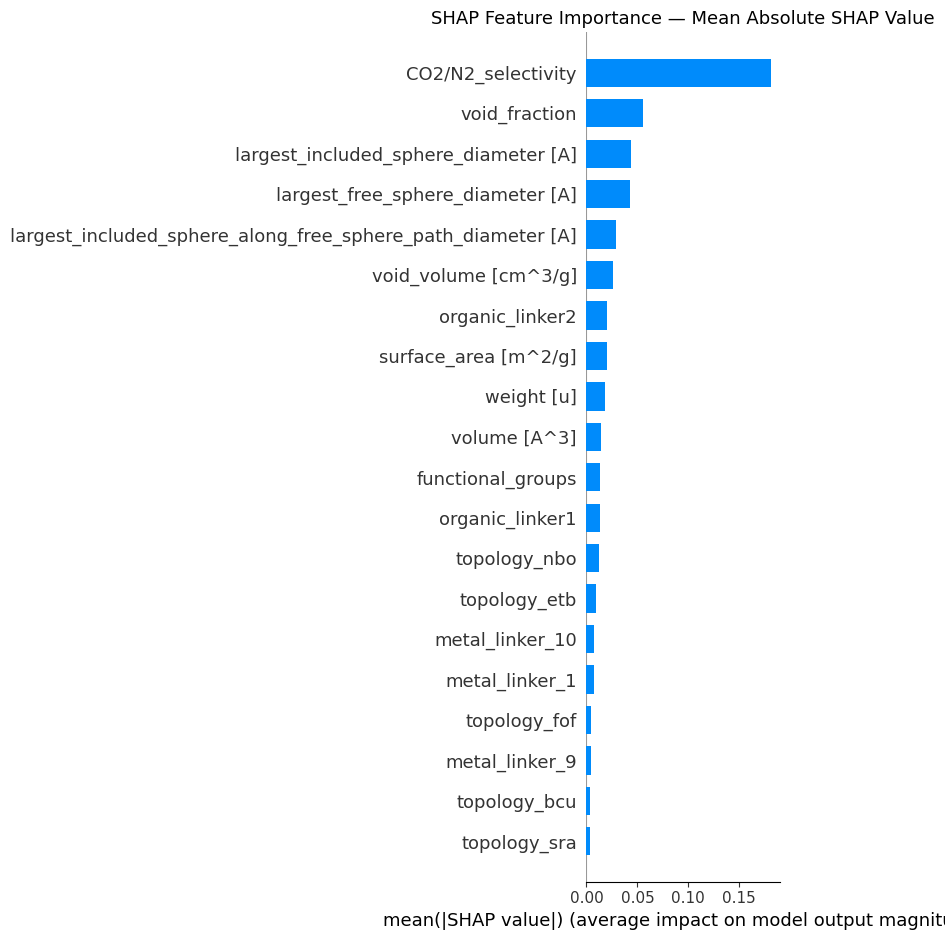

C:\Users\HP\AppData\Local\Temp\ipykernel_20568\1687846395.py:76: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


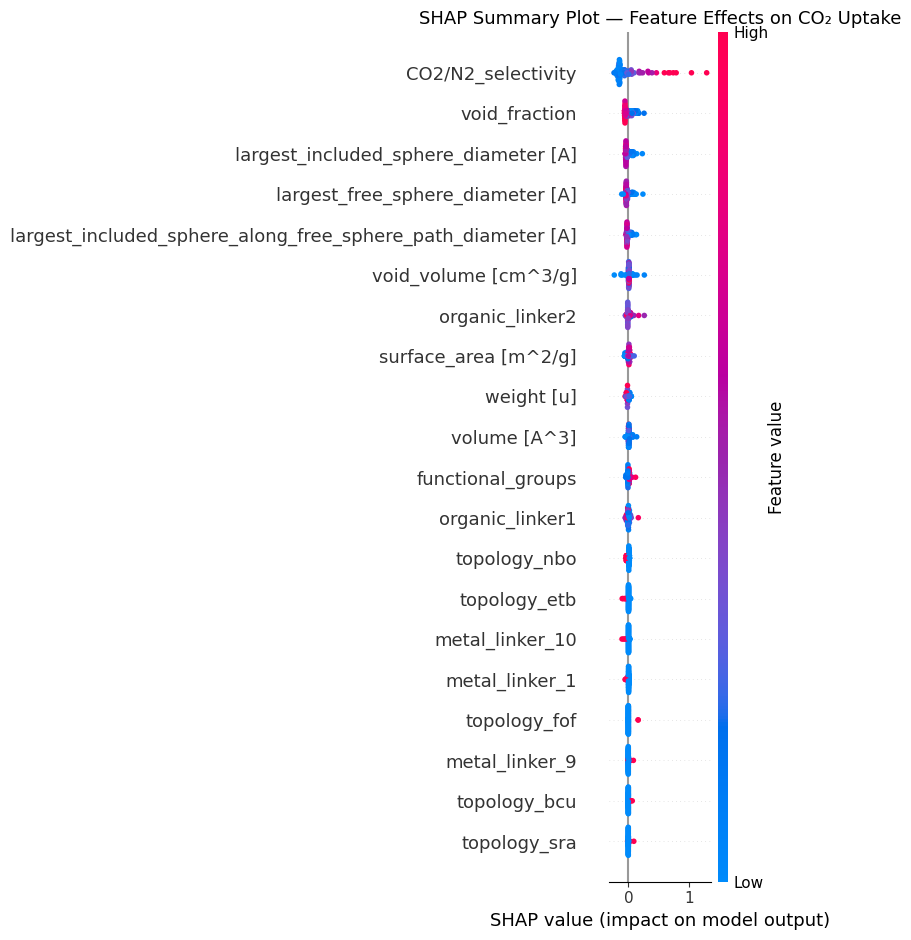

<Figure size 800x500 with 0 Axes>

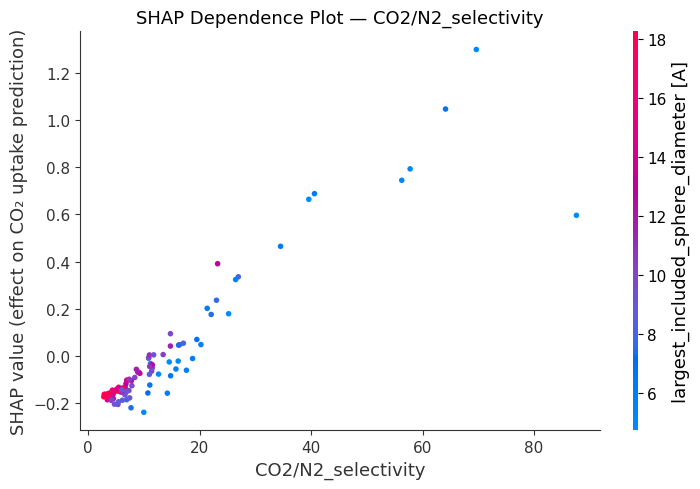

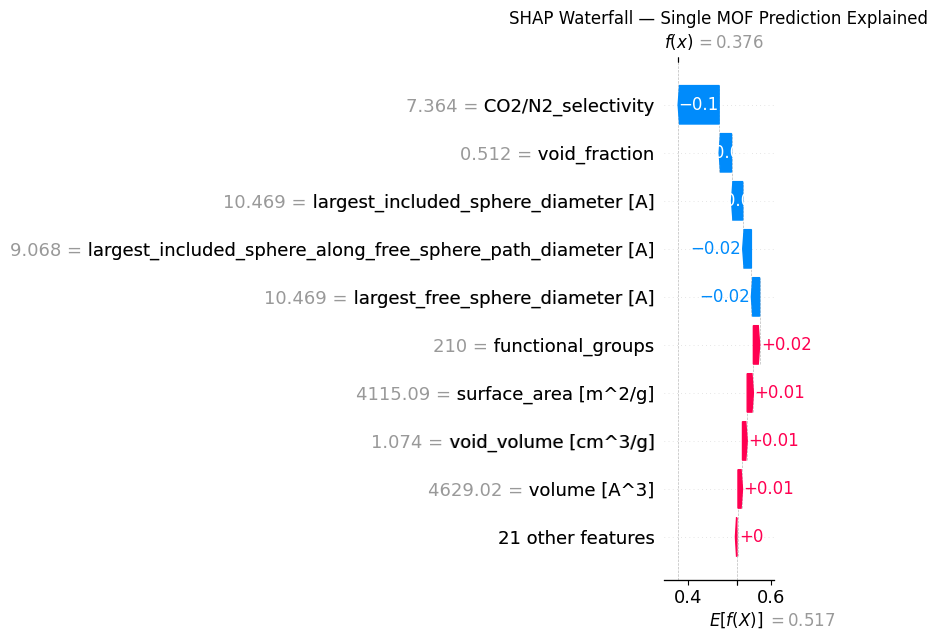


SHAP Feature Importance Table:
                                                    feature  mean_abs_shap     mean_shap
                                         CO2/N2_selectivity       0.180944 -9.914025e-03
                                              void_fraction       0.055913  5.126761e-03
                       largest_included_sphere_diameter [A]       0.043647 -6.035119e-03
                           largest_free_sphere_diameter [A]       0.043088 -3.396441e-03
largest_included_sphere_along_free_sphere_path_diameter [A]       0.029295 -2.430529e-03
                                       void_volume [cm^3/g]       0.026005  1.171865e-02
                                            organic_linker2       0.020602  4.515949e-03
                                       surface_area [m^2/g]       0.019787  4.577970e-04
                                                 weight [u]       0.018094 -2.909037e-03
                                               volume [A^3]       0.014377  6.

In [24]:
explainer = shap.TreeExplainer(rf)
print("SHAP explainer created!")

# ── STEP 1: SAMPLE 100 TEST ROWS ────────────────────────────
sample_size = 100
np.random.seed(42)
sample_indices = np.random.choice(
    len(x_test),
    size=sample_size,
    replace=False
)
x_test_sample = x_test.iloc[sample_indices].values
print("x_test_sample shape:", x_test_sample.shape)

# ── STEP 2: COMPUTE SHAP VALUES ──────────────────────────────
print("Computing SHAP values for 100 test samples...")

shap_values = explainer.shap_values(x_test_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[0]
    print("Converted list to array")

print("SHAP values computed!")
print("Shape of shap_values:", shap_values.shape)

# ── STEP 3: FEATURE NAMES ────────────────────────────────────
feature_names = x.columns.tolist()
print("Number of features:", len(feature_names))


# ── STEP 4: BASE VALUE ───────────────────────────────────────
# ERROR 2 FIX — safe extraction for Random Forest
if hasattr(explainer.expected_value, '__len__'):
    base_value = float(explainer.expected_value[0])
else:
    base_value = float(explainer.expected_value)

print("Base value:", round(base_value, 4))


# ── STEP 5: CALCULATE MEAN SHAP FIRST ────────────────────────

mean_shap = pd.DataFrame({
    'feature':       feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'mean_shap':     shap_values.mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 5 most important features:")
print(mean_shap.head().to_string(index=False))

# ERROR FIX — get actual most important feature name
most_important_feature = mean_shap.iloc[0]['feature']
print("\nMost important feature:", most_important_feature)


# ── PLOT 1: BAR PLOT ─────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    x_test_sample,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — Mean Absolute SHAP Value',
          fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


# ── PLOT 2: DOT PLOT ─────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    x_test_sample,
    feature_names=feature_names,
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary Plot — Feature Effects on CO₂ Uptake',
          fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


# ── PLOT 3: DEPENDENCE PLOT ──────────────────────────────────
# ERROR 4 FIX — uses actual most important feature
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    most_important_feature,
    shap_values,
    x_test_sample,
    feature_names=feature_names,
    interaction_index='auto',
    show=False
)
plt.title(f'SHAP Dependence Plot — {most_important_feature}',
          fontsize=13)
plt.xlabel(most_important_feature)
plt.ylabel('SHAP value (effect on CO₂ uptake prediction)')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CREATE EXPLANATION OBJECTS ───────────────────────────────
row_to_explain = 0

# single row — for waterfall and force plot
shap_explanation_single = shap.Explanation(
    values=shap_values[row_to_explain],
    base_values=base_value,
    data=x_test_sample[row_to_explain],
    feature_names=feature_names
)

# all rows — for heatmap
shap_explanation_all = shap.Explanation(
    values=shap_values,
    base_values=base_value,
    data=x_test_sample,
    feature_names=feature_names
)


# ── PLOT 4: WATERFALL PLOT ───────────────────────────────────
plt.figure()
shap.plots.waterfall(
    shap_explanation_single,
    show=False
)
plt.title('SHAP Waterfall — Single MOF Prediction Explained',
          fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP SUMMARY TABLE ───────────────────────────────────────
# already calculated above — just print again here
print("\nSHAP Feature Importance Table:")
print("="*60)
print(mean_shap.to_string(index=False))
print("\nTop 5 most influential features:")
print(mean_shap.head())